In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ---- Original compensation values ----
t_ms = np.arange(0, 400001, 100)
comp = np.zeros_like(t_ms, dtype=int)
for i, t in enumerate(t_ms):
    if t < 30000: comp[i] = 18
    elif t < 40000: comp[i] = 17
    elif t < 50000: comp[i] = 16
    elif t < 60000: comp[i] = 15
    elif t < 70000: comp[i] = 14
    elif t < 80000: comp[i] = 13
    elif t < 90000: comp[i] = 12
    elif t < 105000: comp[i] = 11
    elif t < 120000: comp[i] = 10
    elif t < 150000: comp[i] = 9
    elif t < 165000: comp[i] = 8
    elif t < 180000: comp[i] = 7
    elif t < 210000: comp[i] = 6
    elif t < 240000: comp[i] = 5
    elif t < 270000: comp[i] = 4
    elif t < 300000: comp[i] = 3
    elif t < 360000: comp[i] = 2
    else: comp[i] = 0

t_s = t_ms / 1000.0

In [2]:
# Development version of the preheat time logic.

CHANGE_THRESHOLD = 1
CHANGE_TIMESPAN = 2*60  # seconds

def detect_preheat_end(df):
    he_span = 550

    prev_time = df["time"].iloc[0]
    prev_val = df["he_mv"].iloc[0]

    for i in range(1, len(df)):
        now = df["time"].iloc[i]
        val = df["he_mv"].iloc[i]
        ratio = (abs(val - prev_val) / he_span) / (now - prev_time) * CHANGE_TIMESPAN * 100

        if ratio < CHANGE_THRESHOLD:
            return now

        prev_time = now
        prev_val = val

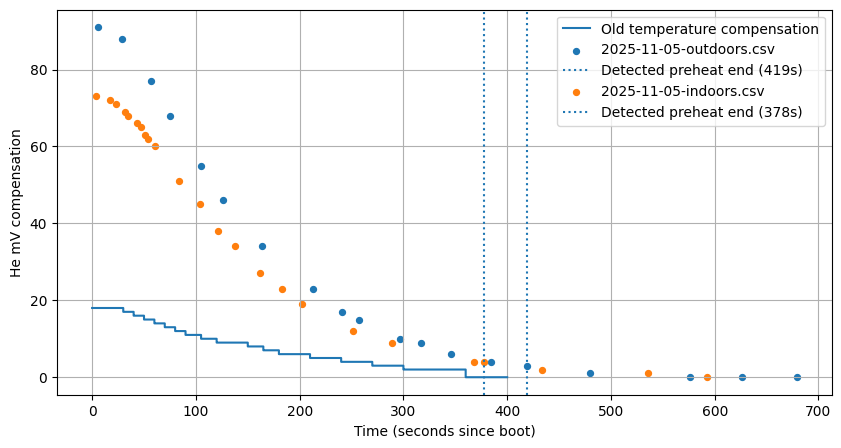

In [3]:
plt.figure(figsize=(10,5))
plt.step(t_s, comp, where='post', label="Old temperature compensation")

folder = "data/temperature_comp_measurements"
files = glob.glob(os.path.join(folder, "*.csv"))
for file in files:
    df = pd.read_csv(file, comment="#")
    df["he_mv_compensation"] = df["he_mv"] - df["he_mv"].min()
    label = os.path.basename(file)
    plt.scatter(df.time, df.he_mv_compensation, label=label, s=18)
    end_time = detect_preheat_end(df)
    plt.axvline(end_time, linestyle=':', label=f"Detected preheat end ({end_time:.0f}s)")

plt.xlabel("Time (seconds since boot)")
plt.ylabel("He mV compensation")
plt.legend()
plt.grid(True)
plt.show()